In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================================================
# STEP 1: Load Data & Explore Basic Properties
# ============================================================================

# Load the CSV
df = pd.read_csv('../data/raw/bank_churn.csv')

print("=" * 80)
print("DATA SHAPE & INFO")
print("=" * 80)
print(f"Dataset shape: {df.shape}")  # rows, columns
print(f"\nColumn names and types:")
print(df.dtypes)

print("\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
print(df.head())

print("\n" + "=" * 80)
print("NULL VALUES & DUPLICATES")
print("=" * 80)
print(f"Null values per column:")
print(df.isnull().sum())
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

print("\n" + "=" * 80)
print("BASIC STATISTICS")
print("=" * 80)
print(df.describe())

print("\n" + "=" * 80)
print("CHURN DISTRIBUTION (Target Variable)")
print("=" * 80)
print(df['churn'].value_counts())
print(f"\nChurn rate: {df['churn'].mean()*100:.2f}%")

DATA SHAPE & INFO
Dataset shape: (10000, 12)

Column names and types:
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

FIRST 5 ROWS
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         1013

DETAILED NULL & DUPLICATE ANALYSIS
Empty DataFrame
Columns: [Null Count, Null %]
Index: []
✓ No null values found!

✓ Duplicate rows: 0

CHURN DISTRIBUTION (Class Balance)

Churn = 0 (Not churned): 7963 (79.63%)
Churn = 1 (Churned):     2037 (20.37%)

Class Imbalance Ratio: 3.91:1

✓ Saved: 01_churn_distribution.png


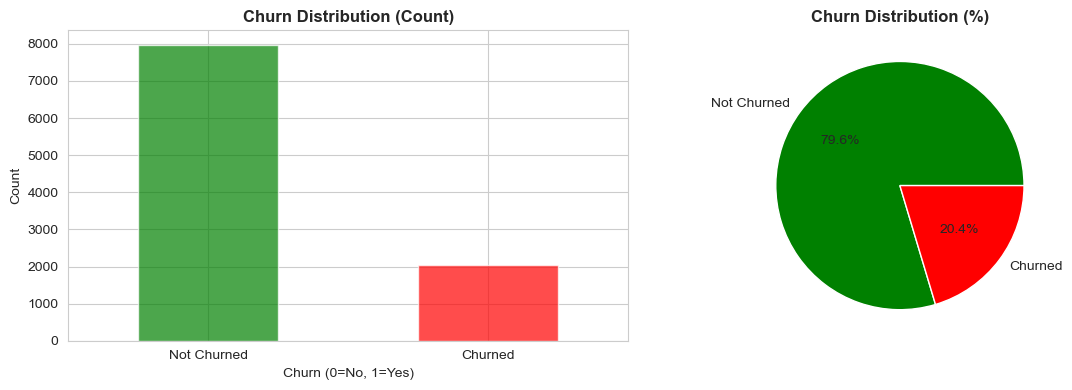


NUMERICAL FEATURES ANALYSIS
Numerical columns: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']

Statistical Summary:
       credit_score           age        tenure        balance  \
count  10000.000000  10000.000000  10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288   
std       96.653299     10.487806      2.892174   62397.405202   
min      350.000000     18.000000      0.000000       0.000000   
25%      584.000000     32.000000      3.000000       0.000000   
50%      652.000000     37.000000      5.000000   97198.540000   
75%      718.000000     44.000000      7.000000  127644.240000   
max      850.000000     92.000000     10.000000  250898.090000   

       products_number  credit_card  active_member  estimated_salary  
count     10000.000000  10000.00000   10000.000000      10000.000000  
mean          1.530200      0.70550       0.515100     100090.239881  
std   

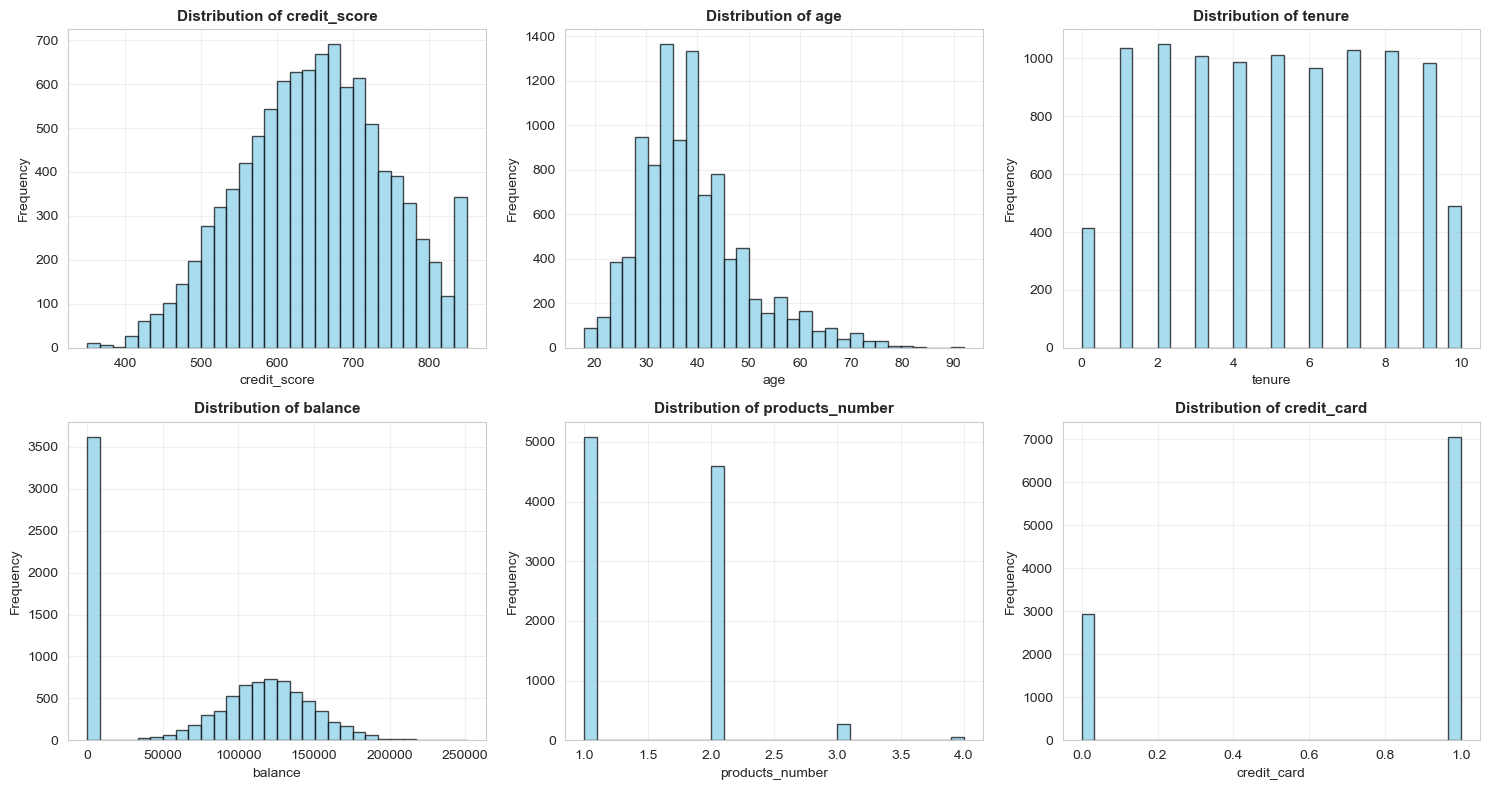


CATEGORICAL FEATURES ANALYSIS
Categorical columns: ['country', 'gender']

country:
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

gender:
gender
Male      5457
Female    4543
Name: count, dtype: int64

✓ Saved: 03_categorical_distributions.png


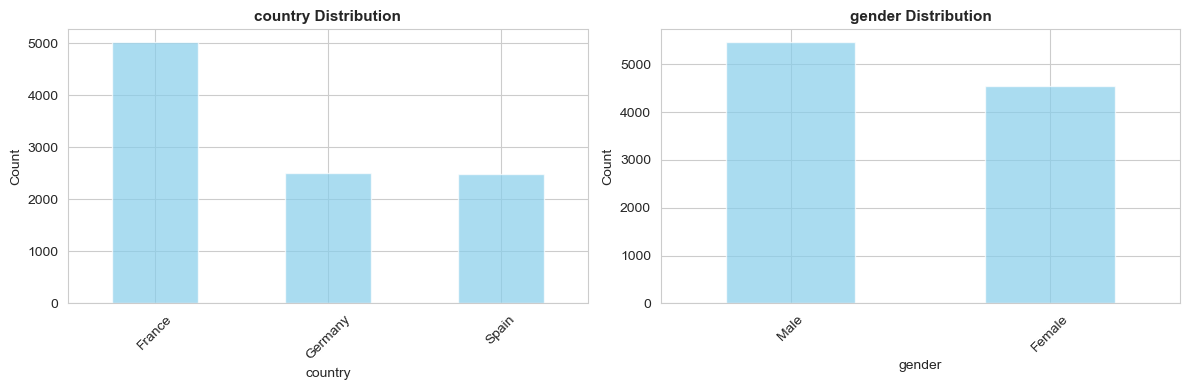


STEP 2 COMPLETE ✓


In [7]:
# ============================================================================
# STEP 2: Exploratory Data Analysis (EDA)
# ============================================================================

print("=" * 80)
print("DETAILED NULL & DUPLICATE ANALYSIS")
print("=" * 80)
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print(null_df[null_df['Null Count'] > 0])
if null_df['Null Count'].sum() == 0:
    print("✓ No null values found!")

print(f"\n✓ Duplicate rows: {df.duplicated().sum()}")

# ============================================================================
print("\n" + "=" * 80)
print("CHURN DISTRIBUTION (Class Balance)")
print("=" * 80)
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100
print(f"\nChurn = 0 (Not churned): {churn_counts[0]} ({churn_pct[0]:.2f}%)")
print(f"Churn = 1 (Churned):     {churn_counts[1]} ({churn_pct[1]:.2f}%)")
print(f"\nClass Imbalance Ratio: {churn_counts[0]/churn_counts[1]:.2f}:1")

# Visualization: Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
churn_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'], alpha=0.7)
axes[0].set_title('Churn Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Churn (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Churned', 'Churned'], rotation=0)

# Pie chart
churn_counts.plot(kind='pie', ax=axes[1], labels=['Not Churned', 'Churned'], 
                  autopct='%1.1f%%', colors=['green', 'red'])
axes[1].set_title('Churn Distribution (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('01_churn_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 01_churn_distribution.png")
plt.show()

# ============================================================================
print("\n" + "=" * 80)
print("NUMERICAL FEATURES ANALYSIS")
print("=" * 80)

# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target variable for now
numerical_cols = [col for col in numerical_cols if col != 'churn' and col != 'customer_id']

print(f"Numerical columns: {numerical_cols}")
print(f"\nStatistical Summary:")
print(df[numerical_cols].describe())

# Visualization: Distributions of numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:6]):  # First 6 numerical features
    axes[idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('02_numerical_distributions.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 02_numerical_distributions.png")
plt.show()

# ============================================================================
print("\n" + "=" * 80)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 80)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

# Visualization: Categorical features
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(12, 4))
if len(categorical_cols) == 1:
    axes = [axes]

for idx, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[idx], color='skyblue', alpha=0.7)
    axes[idx].set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('03_categorical_distributions.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 03_categorical_distributions.png")
plt.show()

# ============================================================================
print("\n" + "=" * 80)
print("STEP 2 COMPLETE ✓")
print("=" * 80)

CORRELATION ANALYSIS

Full Correlation Matrix:
                  credit_score       age    tenure   balance  products_number  \
credit_score          1.000000 -0.003965  0.000842  0.006268         0.012238   
age                  -0.003965  1.000000 -0.009997  0.028308        -0.030680   
tenure                0.000842 -0.009997  1.000000 -0.012254         0.013444   
balance               0.006268  0.028308 -0.012254  1.000000        -0.304180   
products_number       0.012238 -0.030680  0.013444 -0.304180         1.000000   
credit_card          -0.005458 -0.011721  0.022583 -0.014858         0.003183   
active_member         0.025651  0.085472 -0.028362 -0.010084         0.009612   
estimated_salary     -0.001384 -0.007201  0.007784  0.012797         0.014204   
churn                -0.027094  0.285323 -0.014001  0.118533        -0.047820   

                  credit_card  active_member  estimated_salary     churn  
credit_score        -0.005458       0.025651         -0.001384 -0.0

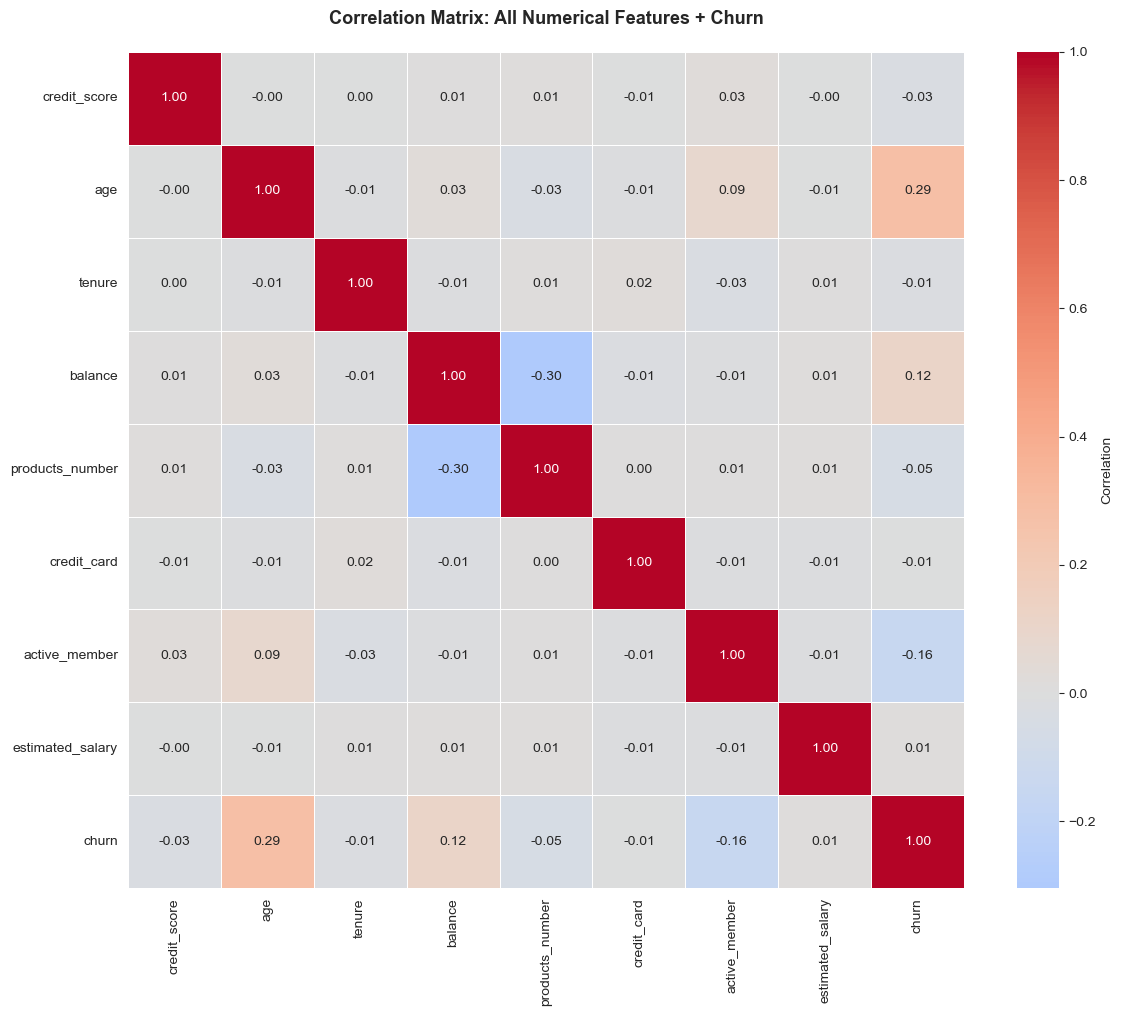


CHURN VS NUMERICAL FEATURES (Box Plots)
✓ Saved: 05_numerical_vs_churn_boxplots.png


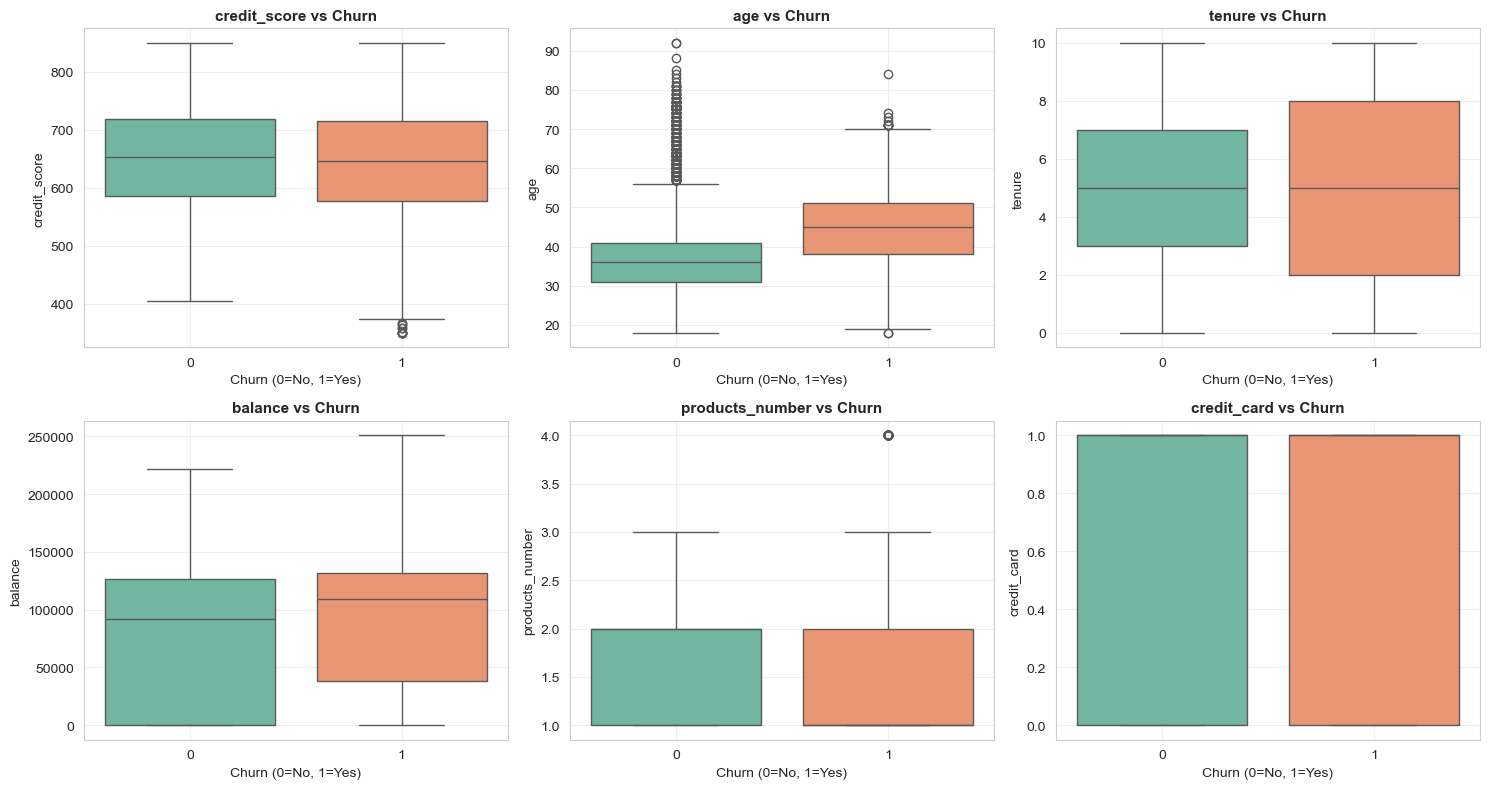


CHURN VS CATEGORICAL FEATURES (Bar Plots)
✓ Saved: 06_categorical_vs_churn_bars.png


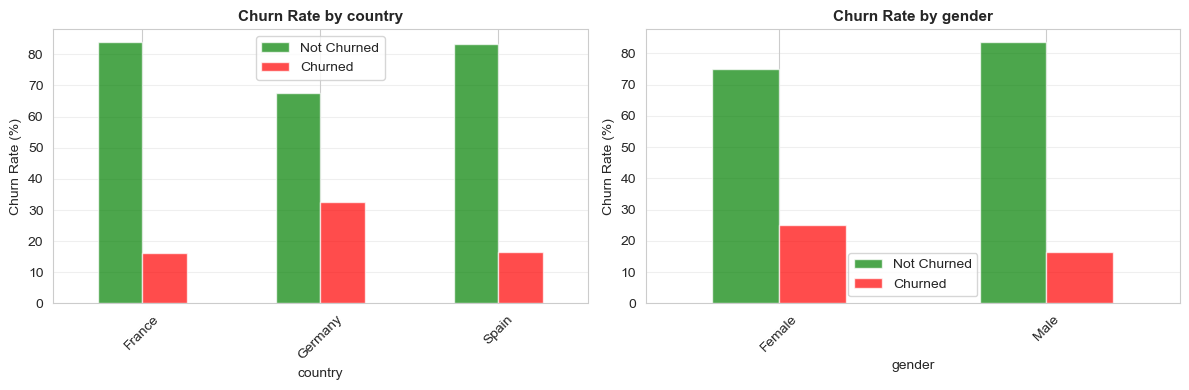


DETAILED CHURN BREAKDOWN BY CATEGORY

COUNTRY:
churn       0     1    All  Churn_Rate_%
country                                 
France   4204   810   5014         16.15
Germany  1695   814   2509         32.44
Spain    2064   413   2477         16.67
All      7963  2037  10000           NaN

GENDER:
churn      0     1    All  Churn_Rate_%
gender                                 
Female  3404  1139   4543         25.07
Male    4559   898   5457         16.46
All     7963  2037  10000           NaN

FEATURE INTERACTION: Tenure vs Churn (Special Attention)

Churn Rate by Age Group:
           count  sum <lambda_0>
age_group                       
<30         1968  148      7.52%
30-40       4451  538     12.09%
40-50       2320  788     33.97%
50+         1261  563     44.65%

Churn Rate by Tenure Group:
              count   sum <lambda_0>
tenure_group                        
<1yr           1448   327     22.58%
1-2yr          1048   201     19.18%
2-3yr          1009   213     21.11%
3

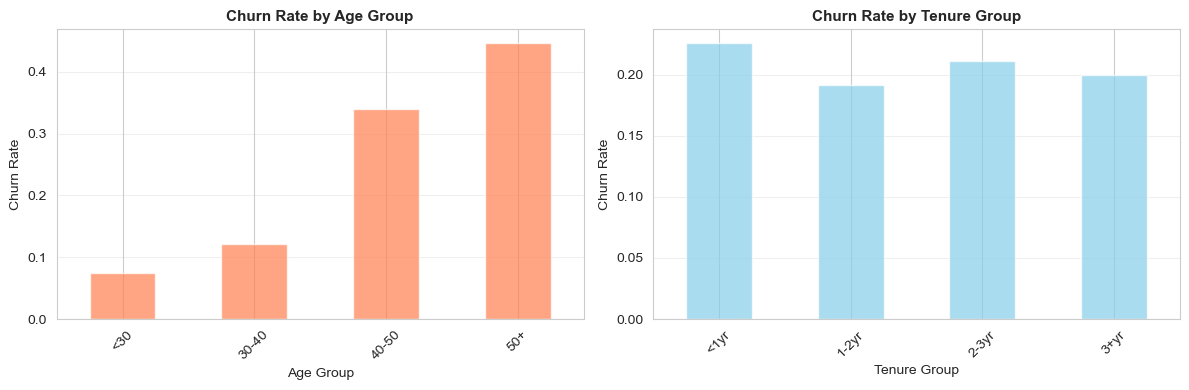


STEP 3 COMPLETE ✓

Key Takeaways:
- High correlation features are most predictive of churn
- Box plots show how feature distributions differ between churned/non-churned
- Categorical features show churn rates by group
- Age & tenure patterns reveal customer lifecycle effects


In [8]:
# ============================================================================
# STEP 3: Correlation & Feature Relationships
# ============================================================================

print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Calculate correlation matrix (only numerical columns)
correlation_matrix = df[numerical_cols + ['churn']].corr()

print("\nFull Correlation Matrix:")
print(correlation_matrix)

# ============================================================================
print("\n" + "=" * 80)
print("CORRELATION WITH CHURN (Target Variable)")
print("=" * 80)

# Extract correlation with churn and sort by absolute value
churn_correlation = correlation_matrix['churn'].sort_values(ascending=False)
print(churn_correlation)

print("\n--- Key Insights ---")
print("Top 5 features MOST correlated with churn (positive & negative):")
for idx, (feature, corr) in enumerate(churn_correlation[1:6].items(), 1):
    print(f"{idx}. {feature}: {corr:.4f}")

# ============================================================================
print("\n" + "=" * 80)
print("CORRELATION HEATMAP (All Numerical Features + Churn)")
print("=" * 80)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Correlation'}, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: All Numerical Features + Churn', 
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 04_correlation_heatmap.png")
plt.show()

# ============================================================================
print("\n" + "=" * 80)
print("CHURN VS NUMERICAL FEATURES (Box Plots)")
print("=" * 80)

# Create box plots for each numerical feature vs churn
# Create box plots for each numerical feature vs churn
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:6]):
    # FIXED: Added hue='churn' and legend=False
    sns.boxplot(
        data=df,
        x='churn',
        y=col,
        ax=axes[idx],
        hue='churn',
        palette='Set2',
        legend=False,
    )
    axes[idx].set_title(f'{col} vs Churn', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Churn (0=No, 1=Yes)')
    axes[idx].set_ylabel(col)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('05_numerical_vs_churn_boxplots.png', dpi=300, bbox_inches='tight')
print('✓ Saved: 05_numerical_vs_churn_boxplots.png')
plt.show()

# ============================================================================
print("\n" + "=" * 80)
print("CHURN VS CATEGORICAL FEATURES (Bar Plots)")
print("=" * 80)

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(12, 4))
if len(categorical_cols) == 1:
    axes = [axes]

for idx, col in enumerate(categorical_cols):
    # Cross-tabulation: show churn rate by category
    crosstab = pd.crosstab(df[col], df['churn'], normalize='index') * 100
    crosstab.plot(kind='bar', ax=axes[idx], color=['green', 'red'], alpha=0.7)
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].legend(['Not Churned', 'Churned'], loc='best')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('06_categorical_vs_churn_bars.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 06_categorical_vs_churn_bars.png")
plt.show()

# ============================================================================
print("\n" + "=" * 80)
print("DETAILED CHURN BREAKDOWN BY CATEGORY")
print("=" * 80)

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    churn_by_category = pd.crosstab(df[col], df['churn'], margins=True)
    churn_by_category['Churn_Rate_%'] = (df.groupby(col, observed=False)['churn'].mean() * 100).round(2)
    print(churn_by_category)

# ============================================================================
print("\n" + "=" * 80)
print("FEATURE INTERACTION: Tenure vs Churn (Special Attention)")
print("=" * 80)

# Create age groups to see patterns
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 100], 
                          labels=['<30', '30-40', '40-50', '50+'])
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1, 1, 2, 3, 10], 
                             labels=['<1yr', '1-2yr', '2-3yr', '3+yr'])

print("\nChurn Rate by Age Group:")
print(df.groupby('age_group', observed=False)['churn'].agg(['count', 'sum', lambda x: f"{x.mean()*100:.2f}%"]))

print("\nChurn Rate by Tenure Group:")
print(df.groupby('tenure_group', observed=False)['churn'].agg(['count', 'sum', lambda x: f"{x.mean()*100:.2f}%"]))

# Visualization: Age vs Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('age_group', observed=False)['churn'].mean().plot(kind='bar', ax=axes[0], color='coral', alpha=0.7)
axes[0].set_title('Churn Rate by Age Group', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('Age Group')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')

df.groupby('tenure_group', observed=False)['churn'].mean().plot(kind='bar', ax=axes[1], color='skyblue', alpha=0.7)
axes[1].set_title('Churn Rate by Tenure Group', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].set_xlabel('Tenure Group')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('07_age_tenure_churn_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 07_age_tenure_churn_analysis.png")
plt.show()

# ============================================================================
print("\n" + "=" * 80)
print("STEP 3 COMPLETE ✓")
print("=" * 80)
print("\nKey Takeaways:")
print("- High correlation features are most predictive of churn")
print("- Box plots show how feature distributions differ between churned/non-churned")
print("- Categorical features show churn rates by group")
print("- Age & tenure patterns reveal customer lifecycle effects")

In [9]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ============================================================================
# STEP 4: Feature Engineering
# ============================================================================

print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# Create a copy to avoid modifying original data
df_engineered = df.copy()

# Drop age_group and tenure_group (temporary columns from Step 3)
df_engineered = df_engineered.drop(['age_group', 'tenure_group'], axis=1)

# ============================================================================
print("\n" + "=" * 80)
print("1. REMOVE UNNECESSARY COLUMNS")
print("=" * 80)

# Remove customer_id (not useful for prediction)
df_engineered = df_engineered.drop('customer_id', axis=1)
print("✓ Dropped: customer_id")
print(f"Remaining columns: {df_engineered.shape[1]}")

# ============================================================================
print("\n" + "=" * 80)
print("2. ENCODE CATEGORICAL VARIABLES")
print("=" * 80)

# Separate target from features
X = df_engineered.drop('churn', axis=1)
y = df_engineered['churn']

print(f"\nCategorical columns to encode: {categorical_cols}")

# One-hot encoding for country and gender
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print(f"\nShape before encoding: {X.shape}")
print(f"Shape after encoding: {X_encoded.shape}")
print(f"\nNew columns after encoding:")
print(X_encoded.columns.tolist())

# ============================================================================
print("\n" + "=" * 80)
print("3. IDENTIFY & SCALE NUMERICAL FEATURES")
print("=" * 80)

# Get numerical column names (after dropping categorical)
numerical_features = [col for col in X_encoded.columns if col not in 
                      [c for cat_col in categorical_cols for c in X_encoded.columns if cat_col in c]]

print(f"Numerical features to scale: {numerical_features}")

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform numerical features
X_encoded[numerical_features] = scaler.fit_transform(X_encoded[numerical_features])

print("\n✓ Scaled numerical features (mean=0, std=1)")
print("\nScaled data sample:")
print(X_encoded.head())

# ============================================================================
print("\n" + "=" * 80)
print("4. CHECK SCALED STATISTICS")
print("=" * 80)

print(f"\nMean of scaled features (should be ~0):")
print(X_encoded[numerical_features].mean().round(4))

print(f"\nStandard deviation of scaled features (should be ~1):")
print(X_encoded[numerical_features].std().round(4))

# ============================================================================
print("\n" + "=" * 80)
print("5. FINAL FEATURE SET")
print("=" * 80)

print(f"\nTotal features after engineering: {X_encoded.shape[1]}")
print(f"Total samples: {X_encoded.shape[0]}")
print(f"\nAll features:")
for idx, col in enumerate(X_encoded.columns, 1):
    print(f"  {idx}. {col}")

# ============================================================================
print("\n" + "=" * 80)
print("6. PREPARE FEATURE METADATA FOR LATER USE")
print("=" * 80)

# Save feature names and scaler info
feature_names = X_encoded.columns.tolist()
feature_info = {
    'feature_names': feature_names,
    'numerical_features': numerical_features,
    'categorical_features': categorical_cols,
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_
}

print("\n✓ Feature metadata prepared:")
print(f"  - Total features: {len(feature_names)}")
print(f"  - Numerical features: {len(numerical_features)}")
print(f"  - Categorical features (one-hot encoded): {X_encoded.shape[1] - len(numerical_features)}")

# ============================================================================
print("\n" + "=" * 80)
print("7. DATA QUALITY CHECK")
print("=" * 80)

print(f"\nNull values in engineered features:")
print(X_encoded.isnull().sum().sum())  # Should be 0

print(f"\nNull values in target:")
print(y.isnull().sum())  # Should be 0

print(f"\nTarget distribution:")
print(y.value_counts())

print(f"\nFeature ranges (sample):")
print(X_encoded.iloc[:, :5].describe())

# ============================================================================
print("\n" + "=" * 80)
print("8. SAVE ENGINEERED FEATURES & TARGET")
print("=" * 80)

# Create final dataframe with engineered features + target
df_final = X_encoded.copy()
df_final['churn'] = y.values

# Inspect final dataset
print(f"\nFinal dataset shape: {df_final.shape}")
print(f"Final dataset columns: {df_final.columns.tolist()}")
print(f"\nFirst 5 rows of engineered data:")
print(df_final.head())

# ============================================================================
print("\n" + "=" * 80)
print("STEP 4 COMPLETE ✓")
print("=" * 80)
print("\nSummary:")
print(f"✓ Removed unnecessary columns (customer_id)")
print(f"✓ One-hot encoded categorical features (country, gender)")
print(f"✓ Standardized numerical features (mean=0, std=1)")
print(f"✓ Final feature count: {X_encoded.shape[1]}")
print(f"✓ Total samples: {X_encoded.shape[0]}")
print(f"\nReady for: Train/Test/Validation Split (STEP 5)")

FEATURE ENGINEERING

1. REMOVE UNNECESSARY COLUMNS
✓ Dropped: customer_id
Remaining columns: 11

2. ENCODE CATEGORICAL VARIABLES

Categorical columns to encode: ['country', 'gender']

Shape before encoding: (10000, 10)
Shape after encoding: (10000, 13)

New columns after encoding:
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_France', 'country_Germany', 'country_Spain', 'gender_Female', 'gender_Male']

3. IDENTIFY & SCALE NUMERICAL FEATURES
Numerical features to scale: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']

✓ Scaled numerical features (mean=0, std=1)

Scaled data sample:
   credit_score       age    tenure   balance  products_number  credit_card  \
0     -0.326221  0.293517 -1.041760 -1.225848        -0.911583     0.646092   
1     -0.440036  0.198164 -1.387538  0.117350        -0.911583    -1.547768   
2     -1.536794  0.293517  1

CLASS IMBALANCE ANALYSIS & HANDLING

1. ANALYZE CLASS IMBALANCE (BEFORE)

Original class distribution:
churn
0    7963
1    2037
Name: count, dtype: int64

Percentage distribution:
churn
0    79.63
1    20.37
Name: proportion, dtype: float64

Imbalance Ratio: 3.91:1
  (For every 3 non-churned, there is 1 churned)

⚠️  SIGNIFICANT IMBALANCE DETECTED!
   Using SMOTE to balance classes...

2. APPLY SMOTE (Synthetic Minority Over-sampling Technique)

✓ SMOTE applied!

New class distribution (AFTER SMOTE):
Class 0 (Not Churned): 7963
Class 1 (Churned):     7963

Percentage distribution:
  Class 0: 50.00%
  Class 1: 50.00%

3. VISUALIZE CLASS BALANCE (BEFORE vs AFTER)

✓ Saved: 08_class_balance_before_after.png


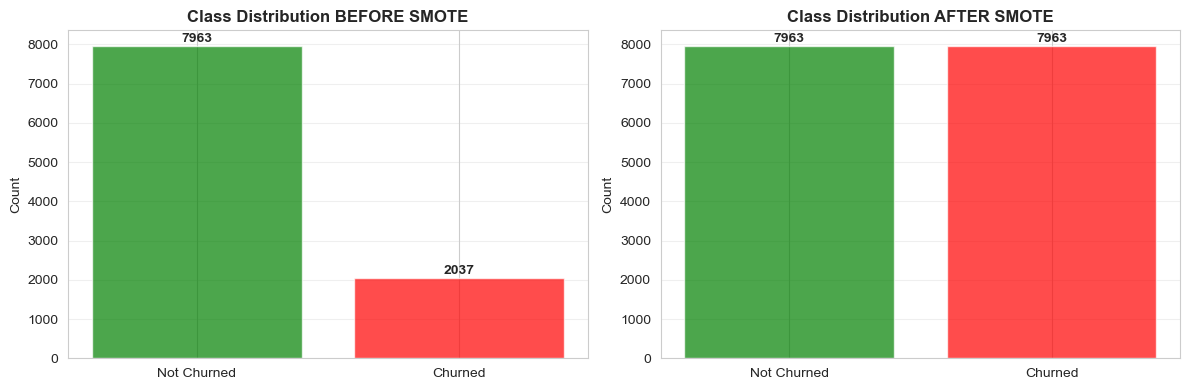


4. VERIFY SMOTE DID NOT CREATE LEAKAGE

Original dataset shape: (10000, 13)
After SMOTE shape: (15926, 13)
New samples created: 5926

Feature statistics BEFORE SMOTE (sample):
       credit_score        age     tenure
count     10000.000  10000.000  10000.000
mean         -0.000      0.000     -0.000
std           1.000      1.000      1.000
min          -3.110     -1.995     -1.733
25%          -0.688     -0.660     -0.696
50%           0.015     -0.183     -0.004
75%           0.698      0.484      0.687
max           2.064      5.061      1.724

Feature statistics AFTER SMOTE (sample):
       credit_score        age     tenure
count     15926.000  15926.000  15926.000
mean         -0.017      0.208     -0.004
std           0.979      0.973      0.983
min          -3.110     -1.995     -1.733
25%          -0.696     -0.469     -0.810
50%          -0.010      0.103     -0.004
75%           0.671      0.775      0.798
max           2.064      5.061      1.724

✓ Statistics preserved -

In [10]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt

# ============================================================================
# STEP 5: Handle Class Imbalance
# ============================================================================

print("=" * 80)
print("CLASS IMBALANCE ANALYSIS & HANDLING")
print("=" * 80)

# Use the engineered data from Step 4
X = df_final.drop('churn', axis=1)
y = df_final['churn']

# ============================================================================
print("\n" + "=" * 80)
print("1. ANALYZE CLASS IMBALANCE (BEFORE)")
print("=" * 80)

print(f"\nOriginal class distribution:")
print(y.value_counts())
print(f"\nPercentage distribution:")
print(y.value_counts(normalize=True) * 100)

class_0_count = (y == 0).sum()
class_1_count = (y == 1).sum()
imbalance_ratio = class_0_count / class_1_count

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"  (For every {int(imbalance_ratio)} non-churned, there is 1 churned)")

if imbalance_ratio > 2:
    print(f"\n⚠️  SIGNIFICANT IMBALANCE DETECTED!")
    print(f"   Using SMOTE to balance classes...")
else:
    print(f"\n✓ Classes relatively balanced")

# ============================================================================
print("\n" + "=" * 80)
print("2. APPLY SMOTE (Synthetic Minority Over-sampling Technique)")
print("=" * 80)

# SMOTE creates synthetic samples of minority class
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X, y)

print(f"\n✓ SMOTE applied!")
print(f"\nNew class distribution (AFTER SMOTE):")
print(f"Class 0 (Not Churned): {(y_smote == 0).sum()}")
print(f"Class 1 (Churned):     {(y_smote == 1).sum()}")
print(f"\nPercentage distribution:")
unique, counts = np.unique(y_smote, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {(c / len(y_smote)) * 100:.2f}%")

# ============================================================================
print("\n" + "=" * 80)
print("3. VISUALIZE CLASS BALANCE (BEFORE vs AFTER)")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
before_counts = y.value_counts()
axes[0].bar(['Not Churned', 'Churned'], before_counts, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Class Distribution BEFORE SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(before_counts):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# After SMOTE
after_counts = pd.Series(y_smote).value_counts()
axes[1].bar(['Not Churned', 'Churned'], [after_counts[0], after_counts[1]], 
            color=['green', 'red'], alpha=0.7)
axes[1].set_title('Class Distribution AFTER SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate([after_counts[0], after_counts[1]]):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('08_class_balance_before_after.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 08_class_balance_before_after.png")
plt.show()

# ============================================================================
print("\n" + "=" * 80)
print("4. VERIFY SMOTE DID NOT CREATE LEAKAGE")
print("=" * 80)

print(f"\nOriginal dataset shape: {X.shape}")
print(f"After SMOTE shape: {X_smote.shape}")
print(f"New samples created: {X_smote.shape[0] - X.shape[0]}")

print(f"\nFeature statistics BEFORE SMOTE (sample):")
print(X.iloc[:, :3].describe().round(3))

print(f"\nFeature statistics AFTER SMOTE (sample):")
print(X_smote.iloc[:, :3].describe().round(3))

print("\n✓ Statistics preserved - SMOTE interpolated within existing data")

# ============================================================================
print("\n" + "=" * 80)
print("5. CREATE BALANCED DATAFRAME")
print("=" * 80)

# Convert numpy arrays back to DataFrame
X_smote_df = pd.DataFrame(X_smote, columns=X.columns)
y_smote_series = pd.Series(y_smote, name='churn')

# Combine features + target
df_balanced = X_smote_df.copy()
df_balanced['churn'] = y_smote_series.values

print(f"\n✓ Balanced dataset created")
print(f"Shape: {df_balanced.shape}")
print(f"\nFirst 5 rows:")
print(df_balanced.head())

# ============================================================================
print("\n" + "=" * 80)
print("6. ALTERNATIVE: CLASS WEIGHTS (for comparison)")
print("=" * 80)

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', 
                                     classes=np.unique(y), 
                                     y=y)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nClass weights (for model training):")
print(f"  Class 0 (Not Churned): {class_weight_dict[0]:.4f}")
print(f"  Class 1 (Churned):     {class_weight_dict[1]:.4f}")
print(f"\nNote: When training models, use class_weight={class_weight_dict}")

# ============================================================================
print("\n" + "=" * 80)
print("STEP 5 COMPLETE ✓")
print("=" * 80)
print("\nSummary:")
print(f"✓ Detected class imbalance (ratio: {imbalance_ratio:.2f}:1)")
print(f"✓ Applied SMOTE to create synthetic minority samples")
print(f"✓ Original samples: {y.shape[0]} → Balanced: {y_smote.shape[0]}")
print(f"✓ Classes now equal: 50% each")
print(f"✓ Balanced dataset ready for train/test split (STEP 6)")
print(f"\n** Important for STEP 6 **")
print(f"Use df_balanced (with SMOTE) for training")
print(f"Use original df_final for final evaluation on real data")

TRAIN/TEST/VALIDATION SPLIT

1. SPLIT STRATEGY

Strategy: 80/20 split, then further divide training set
  - 60% Training (for model training)
  - 20% Validation (for hyperparameter tuning & early stopping)
  - 20% Test (for final evaluation - NEVER seen during training)

Why this split?
  ✓ Test set: Simulates real unseen data
  ✓ Validation set: Prevents overfitting, tunes hyperparameters
  ✓ Training set: Teaches the model


2. FIRST SPLIT: Training (80%) vs Test (20%)

✓ Split completed:
  - Train+Val size: 12740 samples (80.0%)
  - Test size:      3186 samples (20.0%)

3. SECOND SPLIT: Training (60%) vs Validation (20%) from Train+Val

✓ Second split completed:
  - Training size:   9555 samples (60.0%)
  - Validation size: 3185 samples (20.0%)
  - Test size:       3186 samples (20.0%)

4. VERIFY SPLITS (Overall)

Total samples: 15926
  - Training:    9555 ( 60.0%)
  - Validation:  3185 ( 20.0%)
  - Test:        3186 ( 20.0%)

5. CLASS BALANCE CHECK (Each Split)

TRAINING SET:
  Cla

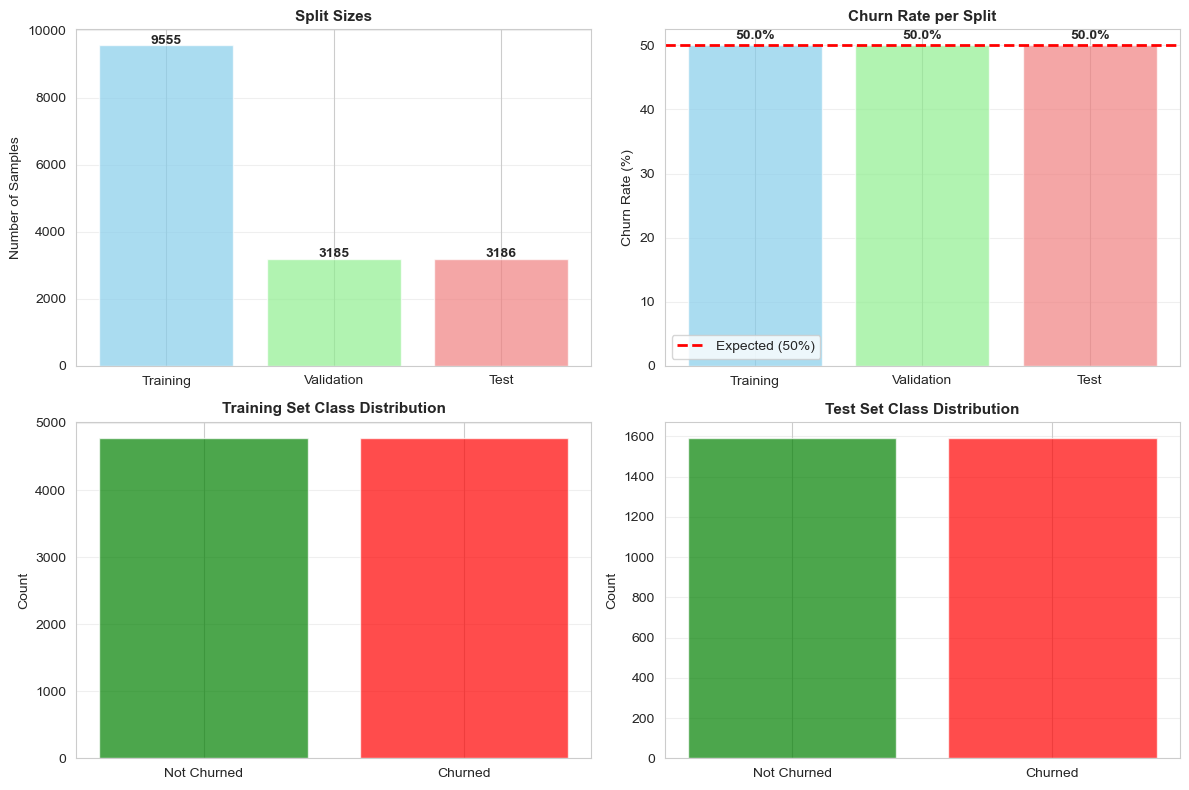


7. FEATURE CONSISTENCY CHECK

Features in each split:
  Training:   13 features
  Validation: 13 features
  Test:       13 features

✓ All splits have the same features: 13

8. CREATE DICTIONARIES FOR EASY ACCESS

✓ Splits dictionary created:
  splits['train']['X']: (9555, 13)
  splits['train']['y']: (9555,)
  splits['val']['X']:   (3185, 13)
  splits['val']['y']:   (3185,)
  splits['test']['X']:  (3186, 13)
  splits['test']['y']:  (3186,)

9. DATA LEAKAGE CHECK

Overlap between splits:
  Train ∩ Val:  0 samples
  Train ∩ Test: 0 samples
  Val ∩ Test:   0 samples

✓ NO DATA LEAKAGE - Splits are completely independent!

10. EXPORT SPLITS FOR ML NOTEBOOK

✓ Saved: splits.joblib
✓ Saved: X_train.csv, y_train.csv, X_val.csv, y_val.csv, X_test.csv, y_test.csv

STEP 6 COMPLETE ✓

Summary:
✓ Split data: 60% Training, 20% Validation, 20% Test
✓ Stratified split maintains class balance in each set
✓ No data leakage between splits
✓ All splits have consistent features (13)
✓ Churn rate ~50% in 

In [11]:
from sklearn.model_selection import train_test_split

# ============================================================================
# STEP 6: Train/Test/Validation Split
# ============================================================================

print("=" * 80)
print("TRAIN/TEST/VALIDATION SPLIT")
print("=" * 80)

# Use balanced data from Step 5
X_balanced = df_balanced.drop('churn', axis=1)
y_balanced = df_balanced['churn']

# ============================================================================
print("\n" + "=" * 80)
print("1. SPLIT STRATEGY")
print("=" * 80)

print("""
Strategy: 80/20 split, then further divide training set
  - 60% Training (for model training)
  - 20% Validation (for hyperparameter tuning & early stopping)
  - 20% Test (for final evaluation - NEVER seen during training)

Why this split?
  ✓ Test set: Simulates real unseen data
  ✓ Validation set: Prevents overfitting, tunes hyperparameters
  ✓ Training set: Teaches the model
""")

# ============================================================================
print("\n" + "=" * 80)
print("2. FIRST SPLIT: Training (80%) vs Test (20%)")
print("=" * 80)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,           # 20% for test
    random_state=42,         # Reproducibility
    stratify=y_balanced      # Keep class distribution
)

print(f"\n✓ Split completed:")
print(f"  - Train+Val size: {X_train_val.shape[0]} samples ({X_train_val.shape[0]/len(X_balanced)*100:.1f}%)")
print(f"  - Test size:      {X_test.shape[0]} samples ({X_test.shape[0]/len(X_balanced)*100:.1f}%)")

# ============================================================================
print("\n" + "=" * 80)
print("3. SECOND SPLIT: Training (60%) vs Validation (20%) from Train+Val")
print("=" * 80)

# Split 80% data into 75% train and 25% validation (0.75 * 0.8 = 0.6, 0.25 * 0.8 = 0.2)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,          # 25% of train+val = 20% of total
    random_state=42,
    stratify=y_train_val     # Keep class distribution
)

print(f"\n✓ Second split completed:")
print(f"  - Training size:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X_balanced)*100:.1f}%)")
print(f"  - Validation size: {X_val.shape[0]} samples ({X_val.shape[0]/len(X_balanced)*100:.1f}%)")
print(f"  - Test size:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X_balanced)*100:.1f}%)")

# ============================================================================
print("\n" + "=" * 80)
print("4. VERIFY SPLITS (Overall)")
print("=" * 80)

total_split = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
print(f"\nTotal samples: {total_split}")
print(f"  - Training:   {X_train.shape[0]:5d} ({X_train.shape[0]/total_split*100:5.1f}%)")
print(f"  - Validation: {X_val.shape[0]:5d} ({X_val.shape[0]/total_split*100:5.1f}%)")
print(f"  - Test:       {X_test.shape[0]:5d} ({X_test.shape[0]/total_split*100:5.1f}%)")

# ============================================================================
print("\n" + "=" * 80)
print("5. CLASS BALANCE CHECK (Each Split)")
print("=" * 80)

def check_split_balance(y_split, split_name):
    class_0 = (y_split == 0).sum()
    class_1 = (y_split == 1).sum()
    churn_rate = (y_split == 1).mean() * 100
    print(f"\n{split_name}:")
    print(f"  Class 0 (Not Churned): {class_0:4d} ({class_0/len(y_split)*100:5.1f}%)")
    print(f"  Class 1 (Churned):     {class_1:4d} ({class_1/len(y_split)*100:5.1f}%)")
    print(f"  Churn Rate:            {churn_rate:.2f}%")

check_split_balance(y_train, "TRAINING SET")
check_split_balance(y_val, "VALIDATION SET")
check_split_balance(y_test, "TEST SET")

# ============================================================================
print("\n" + "=" * 80)
print("6. VISUALIZE SPLIT DISTRIBUTION")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Split sizes
split_names = ['Training', 'Validation', 'Test']
split_sizes = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
colors = ['skyblue', 'lightgreen', 'lightcoral']
axes[0, 0].bar(split_names, split_sizes, color=colors, alpha=0.7)
axes[0, 0].set_title('Split Sizes', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].grid(alpha=0.3, axis='y')
for i, v in enumerate(split_sizes):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 2: Churn rate per split
churn_rates = [
    (y_train == 1).mean() * 100,
    (y_val == 1).mean() * 100,
    (y_test == 1).mean() * 100
]
axes[0, 1].bar(split_names, churn_rates, color=colors, alpha=0.7)
axes[0, 1].set_title('Churn Rate per Split', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].axhline(y=50, color='red', linestyle='--', linewidth=2, label='Expected (50%)')
axes[0, 1].grid(alpha=0.3, axis='y')
axes[0, 1].legend()
for i, v in enumerate(churn_rates):
    axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 3: Class distribution - Training
y_train_counts = y_train.value_counts()
axes[1, 0].bar(['Not Churned', 'Churned'], [y_train_counts[0], y_train_counts[1]], 
               color=['green', 'red'], alpha=0.7)
axes[1, 0].set_title('Training Set Class Distribution', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(alpha=0.3, axis='y')

# Plot 4: Class distribution - Test
y_test_counts = y_test.value_counts()
axes[1, 1].bar(['Not Churned', 'Churned'], [y_test_counts[0], y_test_counts[1]], 
               color=['green', 'red'], alpha=0.7)
axes[1, 1].set_title('Test Set Class Distribution', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('09_train_val_test_split.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 09_train_val_test_split.png")
plt.show()

# ============================================================================
print("\n" + "=" * 80)
print("7. FEATURE CONSISTENCY CHECK")
print("=" * 80)

print(f"\nFeatures in each split:")
print(f"  Training:   {X_train.shape[1]} features")
print(f"  Validation: {X_val.shape[1]} features")
print(f"  Test:       {X_test.shape[1]} features")

print(f"\n✓ All splits have the same features: {X_train.shape[1]}")

# ============================================================================
print("\n" + "=" * 80)
print("8. CREATE DICTIONARIES FOR EASY ACCESS")
print("=" * 80)

# Create split dictionaries for easy access
splits = {
    'train': {'X': X_train, 'y': y_train},
    'val': {'X': X_val, 'y': y_val},
    'test': {'X': X_test, 'y': y_test}
}

print(f"\n✓ Splits dictionary created:")
print(f"  splits['train']['X']: {splits['train']['X'].shape}")
print(f"  splits['train']['y']: {splits['train']['y'].shape}")
print(f"  splits['val']['X']:   {splits['val']['X'].shape}")
print(f"  splits['val']['y']:   {splits['val']['y'].shape}")
print(f"  splits['test']['X']:  {splits['test']['X'].shape}")
print(f"  splits['test']['y']:  {splits['test']['y'].shape}")

# ============================================================================
print("\n" + "=" * 80)
print("9. DATA LEAKAGE CHECK")
print("=" * 80)

# Verify no overlap between splits
train_indices = set(X_train.index)
val_indices = set(X_val.index)
test_indices = set(X_test.index)

overlap_train_val = len(train_indices & val_indices)
overlap_train_test = len(train_indices & test_indices)
overlap_val_test = len(val_indices & test_indices)

print(f"\nOverlap between splits:")
print(f"  Train ∩ Val:  {overlap_train_val} samples")
print(f"  Train ∩ Test: {overlap_train_test} samples")
print(f"  Val ∩ Test:   {overlap_val_test} samples")

if overlap_train_val == 0 and overlap_train_test == 0 and overlap_val_test == 0:
    print(f"\n✓ NO DATA LEAKAGE - Splits are completely independent!")
else:
    print(f"\n⚠️  WARNING: Data leakage detected!")

# ============================================================================
print("\n" + "=" * 80)
print("10. EXPORT SPLITS FOR ML NOTEBOOK")
print("=" * 80)

import joblib

SPLITS_PATH = 'splits.joblib'
joblib.dump(splits, SPLITS_PATH)
print(f"\n✓ Saved: {SPLITS_PATH}")

for split_name in ['train', 'val', 'test']:
    splits[split_name]['X'].to_csv(f'X_{split_name}.csv', index=False)
    splits[split_name]['y'].to_csv(f'y_{split_name}.csv', index=False)

print("✓ Saved: X_train.csv, y_train.csv, X_val.csv, y_val.csv, X_test.csv, y_test.csv")

# ============================================================================
print("\n" + "=" * 80)
print("STEP 6 COMPLETE ✓")
print("=" * 80)
print("\nSummary:")
print(f"✓ Split data: 60% Training, 20% Validation, 20% Test")
print(f"✓ Stratified split maintains class balance in each set")
print(f"✓ No data leakage between splits")
print(f"✓ All splits have consistent features ({X_train.shape[1]})")
print(f"✓ Churn rate ~50% in all splits (as expected from SMOTE)")
print(f"✓ Exported splits to {SPLITS_PATH} and CSV files")
print(f"\nReady for: Phase 2 - ML Model Training")

In [ ]:
print("Scaler Mean:")
print(scaler.mean_)
print("\nScaler Scale (Std):")
print(scaler.scale_)
print("\nNumerical Features:")
print(numerical_features)
print("\nFeature Names (in order):")
print(feature_names)

Scaler Mean:
[6.50528800e+02 3.89218000e+01 5.01280000e+00 7.64858893e+04
 1.53020000e+00 7.05500000e-01 5.15100000e-01 1.00090240e+05]

Scaler Scale (Std):
[9.66484660e+01 1.04872820e+01 2.89202976e+00 6.23942853e+04
 5.81625275e-01 4.55817672e-01 4.99771938e-01 5.75076172e+04]

Numerical Features:
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']

Feature Names (in order):
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_France', 'country_Germany', 'country_Spain', 'gender_Female', 'gender_Male']
